# 🌾 Katalog & Visualisasi Spasial Komprehensif Data Ground Truth
## Inventarisasi Petak Lapangan Padi & Penggunaan Lahan (Klaten: Delanggu & Tulung | Salatiga: Tingkir)
**Peneliti**: M. Hakim GF | **Metodologi**: Penyatuan Dataset Lapangan & Kalibrasi Spasial Klaster Superpixel SNIC

---

### 📌 Latar Belakang & Tujuan Notebook
Akurasi dan reliabilitas model pembelajaran mesin berbasis deret waktu satelit (KNN-DTW) sangat bergantung pada kualitas dan keterwakilan data referensi lapangan (*ground truth*). 

Notebook ini secara khusus didedikasikan untuk **menginventarisasi, memvalidasi, dan memvisualisasikan secara spasial seluruh data lapangan** yang digunakan dalam penelitian Tugas Akhir:
1. **Survei Lapangan Dosen di Kabupaten Klaten (13 Petak)**: Meliputi Kecamatan Delanggu (sentra Rojolele Srinuk) dan Kecamatan Tulung (Inpari 32, Inpari 33, dan Mapan).
2. **Survei Lapangan Dosen di Kota Salatiga (7 Petak)**: Meliputi Kecamatan Tingkir dengan varietas Inpari 32 pada berbagai fase pertumbuhan (1.5 bulan hingga 3.5 bulan).
3. **Petak Terkalibrasi Delanggu (*Tuned Polygons*, 2 Petak)**: Petak sawah Rojolele Srinuk dan Inpari 32 yang telah diselaraskan dengan batas petak resolusi tinggi.
4. **Data Penggunaan Lahan Non-Sawah (4 Area Poligon)**: Sampel pemukiman, kawasan terbangun, infrastruktur jalan, dan badan air di Kecamatan Delanggu.
5. **Klaster Superpixel SNIC Terlabeli (52 Klaster)**: Hasil segmentasi citra satelit beresolusi 10 meter yang terhubung secara spasial dengan ground truth melalui analisis tumpang tindih (*overlay intersection* $\ge 25\%$).

---
## 🗺️ Struktur & Taksonomi Dataset Ground Truth

```
                           DATA GROUND TRUTH TERPADU
                       (Total 26 Petak Lapangan Referensi)
                                       │
        ┌──────────────────────────────┼──────────────────────────────┐
        ▼                              ▼                              ▼
KABUPATEN KLATEN                 KOTA SALATIGA               DATA NON-SAWAH
  (15 Petak Sawah)              (7 Petak Sawah)             (4 Poligon Area)
        │                              │                              │
  ┌─────┴──────────────┐         ┌─────┴──────────────┐         ┌─────┴──────────────┐
  ▼                    ▼         ▼                    ▼         ▼                    ▼
KEC. DELANGGU     KEC. TULUNG   KEC. TINGKIR      FASE UMUR    PEMUKIMAN          JALAN & AIR
- Srinuk (7)      - Inpari 32   - Inpari 32 (7)   - 2 Bulan    - Area Urban       - Badan Air
- Inpari 32 (3)   - Mapan (1)                     - 2.5 Bulan  - Kawasan          - Jalan Raya
- Membramo (1)                                    - 3 Bulan      Industri
                                                  - 3.5 Bulan
                                       │
                                       ▼
                       SPATIAL OVERLAY INTERSECTION (≥25%)
                                       │
                                       ▼
                       52 KLASTER SUPERPIXEL SNIC DELANGGU
                     - 30 Klaster Non-Sawah
                     - 16 Klaster Rojolele Srinuk
                     - 5 Klaster Inpari 32
                     - 1 Klaster Membramo
```

In [1]:
# 1. Memuat Dataset Ground Truth Terpadu & Menghitung Parameter Spasial
import os
import glob
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Path file GeoJSON
unified_gt_path = os.path.join('..', 'data', 'processed', 'unified_ground_truth_all.geojson')
if not os.path.exists(unified_gt_path):
    unified_gt_path = os.path.join('data', 'processed', 'unified_ground_truth_all.geojson')

clusters_labeled_path = os.path.join('..', 'data', 'spatial', 'delanggu_snic_clusters_labeled.geojson')
if not os.path.exists(clusters_labeled_path):
    clusters_labeled_path = os.path.join('data', 'spatial', 'delanggu_snic_clusters_labeled.geojson')

gdf_gt = gpd.read_file(unified_gt_path)
gdf_clusters = gpd.read_file(clusters_labeled_path)

# Hitung Luas Proyeksi UTM Zone 49S (EPSG:32749 - Jawa Bagian Selatan)
gdf_gt_utm = gdf_gt.to_crs(epsg=32749)
gdf_gt['area_m2'] = gdf_gt_utm.geometry.area
gdf_gt['area_ha'] = gdf_gt['area_m2'] / 10000.0

# Ekstrak Centroid (Titik Pusat Geografis)
centroids_utm = gdf_gt_utm.geometry.centroid.to_crs(epsg=4326)
gdf_gt['centroid_lon'] = centroids_utm.x
gdf_gt['centroid_lat'] = centroids_utm.y

# Parsing Nama Kecamatan dan Kabupaten secara Eksplisit
def parse_kecamatan(row):
    src = str(row['source_file']).lower()
    if 'tingkir' in src:
        return 'Tingkir'
    elif 'tulung' in src:
        return 'Tulung'
    elif 'delanggu' in src or row['lokasi'] == 'Delanggu':
        return 'Delanggu'
    return row['lokasi']

def parse_kabupaten(row):
    kec = parse_kecamatan(row)
    if kec == 'Tingkir':
        return 'Kota Salatiga'
    return 'Kabupaten Klaten'

gdf_gt['kecamatan'] = gdf_gt.apply(parse_kecamatan, axis=1)
gdf_gt['kabupaten'] = gdf_gt.apply(parse_kabupaten, axis=1)

print(f"=== RINGKASAN INVENTARISASI DATA GROUND TRUTH ===")
print(f"Total Petak Referensi Lapangan : {len(gdf_gt)} petak")
print(f"Total Klaster SNIC Terlabeli   : {len(gdf_clusters[gdf_clusters['kelas_sawah'] != 'unlabeled'])} klaster")
print(f"Cakupan Wilayah Kabupaten      : {gdf_gt['kabupaten'].unique().tolist()}")
print(f"Cakupan Wilayah Kecamatan      : {gdf_gt['kecamatan'].unique().tolist()}")
print(f"Total Luas Area Ground Truth   : {gdf_gt['area_ha'].sum():.2f} Hektar")


=== RINGKASAN INVENTARISASI DATA GROUND TRUTH ===
Total Petak Referensi Lapangan : 26 petak
Total Klaster SNIC Terlabeli   : 52 klaster
Cakupan Wilayah Kabupaten      : ['Kabupaten Klaten', 'Kota Salatiga']
Cakupan Wilayah Kecamatan      : ['Tulung', 'Delanggu', 'Tingkir']
Total Luas Area Ground Truth   : 150.95 Hektar


In [2]:
# 2. Katalog Lengkap 26 Petak Ground Truth Lapangan
cols_display = ['source_file', 'kabupaten', 'kecamatan', 'kelas_sawah', 'varietas', 'usia_fase', 'area_ha', 'centroid_lat', 'centroid_lon']
df_catalog = gdf_gt[cols_display].sort_values(by=['kabupaten', 'kecamatan', 'varietas']).reset_index(drop=True)

# Tampilkan tabel interaktif
print("=== TABEL INVENTARISASI PETAK LAPANGAN GROUND TRUTH ===")
display(df_catalog)

# Ringkasan per Wilayah & Varietas
pivot_summary = pd.pivot_table(
    gdf_gt, 
    index=['kabupaten', 'kecamatan'], 
    columns='varietas', 
    values='area_ha', 
    aggfunc=['count', 'sum'],
    fill_value=0
)
print("\n=== RINGKASAN JUMLAH & LUASAN (HA) PER KECAMATAN ===")
display(pivot_summary)


=== TABEL INVENTARISASI PETAK LAPANGAN GROUND TRUTH ===


,source_file,kabupaten,kecamatan,kelas_sawah,varietas,usia_fase,area_ha,centroid_lat,centroid_lon
0,"06_Inpari_KecDelanggu_3,5 Bulan.geojson",Kabupaten Klaten,Delanggu,sawah,Inpari 32,"3,5 bulan",0.117902,-7.610332,110.687574
1,08_Inpari_KecDelanggu_3 Bulan.geojson,Kabupaten Klaten,Delanggu,sawah,Inpari 32,3 bulan,0.115513,-7.611719,110.687586
2,delanggu_geojson_tuned.geojson,Kabupaten Klaten,Delanggu,sawah,Inpari 32,terkalibrasi,0.313338,-7.631732,110.684395
3,07_Membramo_KecDelanggu_3 Bulan.geojson,Kabupaten Klaten,Delanggu,sawah,Membramo,3 bulan,0.161662,-7.610707,110.687325
4,05_Rojolele Srinuk_KecDelanggu_1 Bulan 2 Mingg...,Kabupaten Klaten,Delanggu,sawah,Rojolele Srinuk,1 bulan,0.036154,-7.610325,110.686734
5,"09_Rojolele Srinunuk_KecDelanggu_2,5 Bulan.geo...",Kabupaten Klaten,Delanggu,sawah,Rojolele Srinuk,"2,5 bulan",0.238659,-7.609644,110.690648
6,10_Rojolele Srinunuk_KecDelanggu_3 Bulan.geojson,Kabupaten Klaten,Delanggu,sawah,Rojolele Srinuk,3 bulan,0.086075,-7.611958,110.690585
7,11_Rojolele Srinunuk_KecDelanggu_2 Bulan.geojson,Kabupaten Klaten,Delanggu,sawah,Rojolele Srinuk,2 bulan,0.419447,-7.611564,110.692731
8,12_Rojolele Srinunuk_KecDelanggu_1 Minggu.geojson,Kabupaten Klaten,Delanggu,sawah,Rojolele Srinuk,1 minggu,0.223710,-7.611420,110.692549
9,"13_Rojolele Srinunuk_KecDelanggu_1,5 Bulan.geo...",Kabupaten Klaten,Delanggu,sawah,Rojolele Srinuk,"1,5 bulan",0.234032,-7.612496,110.692305



=== RINGKASAN JUMLAH & LUASAN (HA) PER KECAMATAN ===


count                                           \
varietas                   Inpari 32 Mapan Membramo Rojolele Srinuk non-sawah   
kabupaten        kecamatan                                                      
Kabupaten Klaten Delanggu          3     0        1               7         4   
                 Tulung            3     1        0               0         0   
Kota Salatiga    Tingkir           7     0        0               0         0   

                                 sum                                      \
varietas                   Inpari 32     Mapan  Membramo Rojolele Srinuk   
kabupaten        kecamatan                                                 
Kabupaten Klaten Delanggu   0.546753  0.000000  0.161662        2.424918   
                 Tulung     0.563574  0.065305  0.000000        0.000000   
Kota Salatiga    Tingkir    1.493191  0.000000  0.000000        0.000000   

                                        
varietas                     non-sawah  
kabupaten        kecamatan              
Kabupaten Klaten Delanggu   145.699044  
                 Tulung       0.000000  
Kota Salatiga    Tingkir      0.000000

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_47612\1680424811.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=var_counts.index, y=var_counts.values, palette=var_palette, ax=axes[0, 0])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_47612\1680424811.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=gdf_sawah, x='varietas', y='area_ha', palette=var_palette, ax=axes[1, 0])


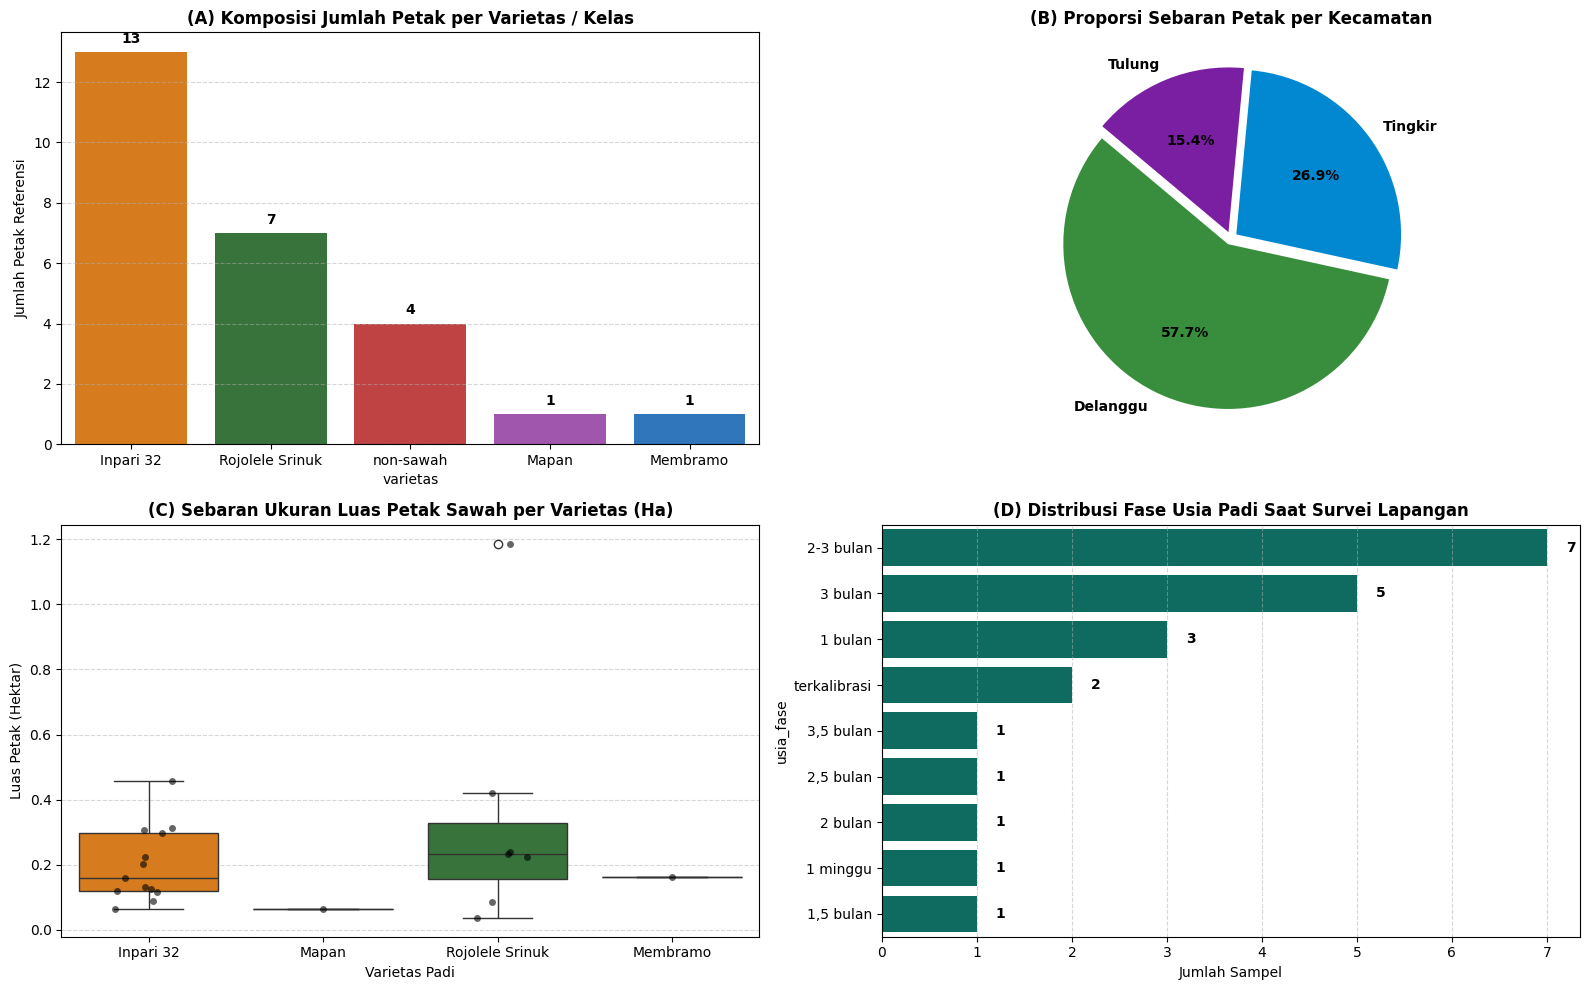

In [3]:
# 3. Analisis Statistik Deskriptif & Karakteristik Spasial Ground Truth
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Warna Khusus Varietas
var_palette = {
    'Rojolele Srinuk': '#2e7d32',
    'Inpari 32': '#f57c00',
    'Membramo': '#1976d2',
    'Mapan': '#ab47bc',
    'non-sawah': '#d32f2f'
}

# Subplot 1: Distribusi Jumlah Sampel per Varietas
var_counts = gdf_gt['varietas'].value_counts()
sns.barplot(x=var_counts.index, y=var_counts.values, palette=var_palette, ax=axes[0, 0])
axes[0, 0].set_title('(A) Komposisi Jumlah Petak per Varietas / Kelas', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Jumlah Petak Referensi')
for i, v in enumerate(var_counts.values):
    axes[0, 0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')
axes[0, 0].grid(True, linestyle='--', alpha=0.5, axis='y')

# Subplot 2: Sebaran Jumlah Petak per Kecamatan
kec_counts = gdf_gt['kecamatan'].value_counts()
colors_kec = ['#388e3c', '#0288d1', '#7b1fa2']
axes[0, 1].pie(kec_counts.values, labels=kec_counts.index, autopct='%1.1f%%', 
               colors=colors_kec, startangle=140, explode=(0.04, 0.04, 0.04),
               textprops={'fontweight': 'bold'})
axes[0, 1].set_title('(B) Proporsi Sebaran Petak per Kecamatan', fontsize=12, fontweight='bold')

# Subplot 3: Distribusi Luas Petak Sawah (Hektar) - Filter Sawah Saja
gdf_sawah = gdf_gt[gdf_gt['kelas_sawah'] == 'sawah']
sns.boxplot(data=gdf_sawah, x='varietas', y='area_ha', palette=var_palette, ax=axes[1, 0])
sns.stripplot(data=gdf_sawah, x='varietas', y='area_ha', color='black', alpha=0.6, jitter=0.2, ax=axes[1, 0])
axes[1, 0].set_title('(C) Sebaran Ukuran Luas Petak Sawah per Varietas (Ha)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Luas Petak (Hektar)')
axes[1, 0].set_xlabel('Varietas Padi')
axes[1, 0].grid(True, linestyle='--', alpha=0.5, axis='y')

# Subplot 4: Sebaran Fase Usia Tanaman Saat Pengambilan Sampel
age_counts = gdf_sawah['usia_fase'].value_counts()
sns.barplot(y=age_counts.index, x=age_counts.values, color='#00796b', ax=axes[1, 1])
axes[1, 1].set_title('(D) Distribusi Fase Usia Padi Saat Survei Lapangan', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Jumlah Sampel')
for i, v in enumerate(age_counts.values):
    axes[1, 1].text(v + 0.2, i, str(v), va='center', fontweight='bold')
axes[1, 1].grid(True, linestyle='--', alpha=0.5, axis='x')

plt.tight_layout()
plt.show()


---
## 🗺️ 4. Peta Spasial Interaktif Multi-Wilayah (Google Basemap)

Peta Leaflet di bawah ini memvisualisasikan seluruh data lapangan secara geospasial presisi tinggi:
- **Pilihan Google Basemap**:
  - **Google Satellite (Hybrid)**: Citra satelit resolusi sangat tinggi dengan label nama jalan, desa, dan batas administrasi.
  - **Google Satellite (Murni)**: Tampilan foto udara alami bebas label.
  - **Google Roadmap**: Peta vektor jalan dan topografi standar Google Maps.
  - **OpenStreetMap**: Peta jaringan jalan terbuka.
- **Lapisan Data Spasial Terpisah (Dapat Dihidupkan/Dimatikan)**:
  - 🟢 **Petak Sawah Kecamatan Delanggu (Klaten)**: Sentra budidaya padi Rojolele Srinuk, Inpari 32, dan Membramo.
  - 🟣 **Petak Sawah Kecamatan Tulung (Klaten)**: Lahan sawah komparasi Inpari 32 & Mapan.
  - 🟠 **Petak Sawah Kecamatan Tingkir (Kota Salatiga)**: Area sawah Inpari 32 multi-fase pertumbuhan.
  - 🔴 **Area Penggunaan Lahan Non-Sawah**: Pemukiman warga, pusat pabrik, jalan raya, dan saluran air.
  - 🧩 **Klaster Superpixel SNIC Terlabeli (52 Klaster)**: Hasil segmentasi citra satelit yang membatasi petak sawah secara alami.
  - 📍 **Titik Pin Lokasi & Informasi Detail**: Klik pada setiap pin atau poligon untuk membuka popup interaktif dengan keterangan varietas, usia tanam, lokasi, luas hektar, dan file sumber.

In [4]:
# 4. Membangun Peta Interaktif Leaflet Multi-Wilayah dengan Google Basemap
import folium
from folium import plugins
from IPython.display import HTML, display

# Hitung titik tengah geospasial seluruh data ground truth (Klaten & Salatiga)
total_bounds = gdf_gt.total_bounds  # [minx, miny, maxx, maxy]
center_lat = (total_bounds[1] + total_bounds[3]) / 2
center_lon = (total_bounds[0] + total_bounds[2]) / 2

# Inisialisasi Peta Folium
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=11,  # Zoom mencakup Klaten dan Salatiga sekaligus
    tiles=None,
    control_scale=True
)

# 1. Menambahkan Lapisan Basemap Google Resolusi Tinggi
folium.TileLayer(
    tiles='https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}',
    attr='Google Satellite Hybrid',
    name='Google Satellite (Hybrid)',
    overlay=False,
    control=True
).add_to(m)

folium.TileLayer(
    tiles='https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',
    attr='Google Satellite',
    name='Google Satellite (Murni)',
    overlay=False,
    control=True
).add_to(m)

folium.TileLayer(
    tiles='https://mt1.google.com/vt/lyrs=m&x={x}&y={y}&z={z}',
    attr='Google Maps',
    name='Google Roadmap',
    overlay=False,
    control=True
).add_to(m)

folium.TileLayer(
    tiles='OpenStreetMap',
    name='OpenStreetMap',
    overlay=False,
    control=True
).add_to(m)

# Palet Warna Khusus untuk Poligon Ground Truth
color_dict = {
    'Rojolele Srinuk': '#00E676',   # Hijau Terang
    'Inpari 32': '#FF9100',        # Oranye
    'Membramo': '#00B0FF',         # Biru Cerah
    'Mapan': '#E040FB',            # Ungu
    'non-sawah': '#FF1744'          # Merah
}

# 2. Layer Group Terpisah Berdasarkan Wilayah
layer_delanggu = folium.FeatureGroup(name='🌾 Sawah Delanggu (Klaten: Srinuk, Inpari, Membramo)', show=True)
layer_tulung = folium.FeatureGroup(name='🌾 Sawah Tulung (Klaten: Inpari 32, Mapan)', show=True)
layer_salatiga = folium.FeatureGroup(name='🌾 Sawah Tingkir (Salatiga: Inpari 32)', show=True)
layer_nonsawah = folium.FeatureGroup(name='🏢 Non-Sawah (Delanggu: Pemukiman & Air)', show=True)
layer_markers = folium.FeatureGroup(name='📍 Titik Pin Survei Lapangan', show=True)

for _, row in gdf_gt.iterrows():
    var = row['varietas']
    col = color_dict.get(var, '#757575')
    kec = row['kecamatan']
    
    popup_html = (
        '<div style="font-family: Arial, sans-serif; width: 250px; font-size: 12px;">'
        f'<h4 style="margin: 0 0 6px 0; color: #1a237e; border-bottom: 2px solid {col}; padding-bottom: 3px;">{var}</h4>'
        '<table style="width: 100%; border-collapse: collapse; line-height: 1.6;">'
        f'<tr><td><b>Wilayah:</b></td><td>{row["kecamatan"]}, {row["kabupaten"]}</td></tr>'
        f'<tr><td><b>Kelas Lahan:</b></td><td>{row["kelas_sawah"]}</td></tr>'
        f'<tr><td><b>Fase Usia:</b></td><td>{row["usia_fase"]}</td></tr>'
        f'<tr><td><b>Luas Area:</b></td><td><b>{row["area_ha"]:.3f} Ha</b> ({row["area_m2"]:.0f} m²)</td></tr>'
        f'<tr><td><b>File Sumber:</b></td><td style="font-size: 10px; color: #555;">{row["source_file"]}</td></tr>'
        '</table></div>'
    )
    
    geo_json = folium.GeoJson(
        row['geometry'],
        style_function=lambda f, c=col: {
            'fillColor': c,
            'fillOpacity': 0.70,
            'color': '#000000',
            'weight': 2.0,
            'opacity': 0.95
        },
        tooltip=f"[{row['kecamatan']}] {var} - {row['area_ha']:.3f} Ha ({row['usia_fase']})",
        popup=folium.Popup(popup_html, max_width=320)
    )
    
    # Masukkan ke Layer Group yang sesuai
    if row['kelas_sawah'] == 'non-sawah':
        geo_json.add_to(layer_nonsawah)
    elif kec == 'Delanggu':
        geo_json.add_to(layer_delanggu)
    elif kec == 'Tulung':
        geo_json.add_to(layer_tulung)
    elif kec == 'Tingkir':
        geo_json.add_to(layer_salatiga)
        
    # Tambahkan Marker Pin
    folium.CircleMarker(
        location=[row['centroid_lat'], row['centroid_lon']],
        radius=5,
        color='#000000',
        weight=1.5,
        fill=True,
        fill_color=col,
        fill_opacity=1.0,
        tooltip=f"{var} ({row['kecamatan']})"
    ).add_to(layer_markers)

layer_delanggu.add_to(m)
layer_tulung.add_to(m)
layer_salatiga.add_to(m)
layer_nonsawah.add_to(m)
layer_markers.add_to(m)

# 3. Layer Klaster Superpixel SNIC Terlabeli di Delanggu (52 Klaster)
layer_clusters = folium.FeatureGroup(name='🧩 Klaster SNIC Terlabeli (52 Klaster Delanggu)', show=False)
gdf_labeled_only = gdf_clusters[gdf_clusters['kelas_sawah'] != 'unlabeled']
for _, row in gdf_labeled_only.iterrows():
    v = row['varietas']
    c_sn = color_dict.get(v, '#9e9e9e')
    folium.GeoJson(
        row['geometry'],
        style_function=lambda f, c=c_sn: {
            'fillColor': c,
            'fillOpacity': 0.45,
            'color': '#ffffff',
            'weight': 1.5,
            'dashArray': '3, 3'
        },
        tooltip=f"Klaster SNIC #{row['cluster_id']}: {v} ({row['area_ha']:.3f} Ha)"
    ).add_to(layer_clusters)
layer_clusters.add_to(m)

# Legenda Peta HTML Elegan
legend_html = '''<div style="position: fixed; 
            bottom: 30px; right: 30px; width: 240px; height: 210px; 
            background-color: white; z-index:9999; font-size:12px;
            border:2px solid #90a4ae; border-radius: 8px; padding: 10px;
            box-shadow: 2px 2px 6px rgba(0,0,0,0.3); font-family: Arial;">
    <p style="margin: 0 0 6px 0; font-weight: bold; font-size: 13px; text-align: center; border-bottom: 1px solid #cfd8dc; padding-bottom: 4px;">Legenda Ground Truth</p>
    <div style="margin-bottom: 4px;"><i style="background: #00E676; width: 14px; height: 14px; display: inline-block; border-radius: 3px; border: 1px solid #000; vertical-align: middle; margin-right: 6px;"></i> Rojolele Srinuk (Klaten)</div>
    <div style="margin-bottom: 4px;"><i style="background: #FF9100; width: 14px; height: 14px; display: inline-block; border-radius: 3px; border: 1px solid #000; vertical-align: middle; margin-right: 6px;"></i> Inpari 32 (Klaten & Salatiga)</div>
    <div style="margin-bottom: 4px;"><i style="background: #00B0FF; width: 14px; height: 14px; display: inline-block; border-radius: 3px; border: 1px solid #000; vertical-align: middle; margin-right: 6px;"></i> Membramo (Klaten)</div>
    <div style="margin-bottom: 4px;"><i style="background: #E040FB; width: 14px; height: 14px; display: inline-block; border-radius: 3px; border: 1px solid #000; vertical-align: middle; margin-right: 6px;"></i> Mapan (Tulung, Klaten)</div>
    <div style="margin-bottom: 4px;"><i style="background: #FF1744; width: 14px; height: 14px; display: inline-block; border-radius: 3px; border: 1px solid #000; vertical-align: middle; margin-right: 6px;"></i> Non-Sawah (Pemukiman/Air)</div>
    <div style="font-size: 10px; color: #546e7a; margin-top: 8px; text-align: center;">Total 26 Petak Asli + 52 Klaster SNIC</div>
</div>'''
m.get_root().html.add_child(folium.Element(legend_html))

folium.LayerControl(position='topright', collapsed=False).add_to(m)
plugins.Fullscreen(position='topleft').add_to(m)

# Simpan ke file HTML mandiri
output_map_html = os.path.join('..', 'outputs', 'maps', 'peta_ground_truth_lengkap_google.html')
if not os.path.exists(os.path.dirname(output_map_html)):
    output_map_html = os.path.join('outputs', 'maps', 'peta_ground_truth_lengkap_google.html')
m.save(output_map_html)

# Banner Bantuan VS Code & Tombol Buka di Browser
helper_banner = (
    '<div style="background-color: #f1f8e9; border: 1px solid #aed581; border-radius: 8px; padding: 12px 16px; margin-bottom: 12px; font-family: Segoe UI, sans-serif;">'
    '<div style="display: flex; align-items: center; justify-content: space-between; flex-wrap: wrap; gap: 8px;">'
    '<div><b style="color: #2e7d32; font-size: 14px;">✅ Peta Interaktif Ground Truth Berhasil Dimuat (Google Satellite & Hybrid)</b>'
    '<p style="margin: 4px 0 0 0; font-size: 12px; color: #455a64;">'
    'Menampilkan 26 petak lapangan (Delanggu, Tulung, Tingkir) dan 52 klaster superpixel SNIC terlabeli.<br>'
    'Jika iframe tertahan oleh keamanan VS Code, Anda dapat langsung mengklik tombol di sebelah kanan:'
    '</p></div>'
    f'<div><a href="{output_map_html}" target="_blank" style="display: inline-block; background-color: #1b5e20; color: white; padding: 8px 18px; border-radius: 5px; text-decoration: none; font-weight: bold; font-size: 12px; box-shadow: 0 2px 4px rgba(0,0,0,0.2);">🗺️ Buka Peta di Browser Baru ↗</a></div>'
    '</div></div>'
)
display(HTML(helper_banner))

# Tampilkan widget peta
m

---
## 🔬 5. Analisis Tumpang Tindih Spasial Klaster Superpixel SNIC (Kecamatan Delanggu)

### 5.1 Formulasi Metodologis Pelabelan Spasial
Pada pemodelan berbasis objek (*Object-Based Image Analysis* / OBIA), data latih model tidak diambil dari koordinat piksel tunggal ($10 \times 10$ m), melainkan dari **rata-rata spektral poligon klaster superpixel SNIC**.
Untuk memetakan label ground truth lapangan ke dalam klaster superpixel, dilakukan operasi interseksi spasial (*Spatial Overlay Intersection*):

$$\text{Overlap Ratio} = \frac{\text{Luas}(\text{Klaster SNIC}_k \cap \text{Petak GT}_j)}{\text{Luas}(\text{Klaster SNIC}_k)}$$

Suatu klaster superpixel $k$ secara definitif diberi label varietas $j$ jika dan hanya jika:
$$\text{Overlap Ratio} \ge 0.25 \quad (25\% \text{ area klaster berada di dalam petak referensi})$$

Hal ini menjamin bahwa sampel deret waktu yang masuk ke dalam model pembelajaran mesin terbebas dari piksel campur (*mixed pixels*) pematang atau jalan raya.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_47612\1984994814.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cl_counts.index, y=cl_counts.values, palette=var_palette, ax=axes[0])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_47612\1984994814.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=luas_comp_filtered, x='Kategori', y='Luas_Ha', palette=['#388e3c', '#0288d1'], ax=axes[1])


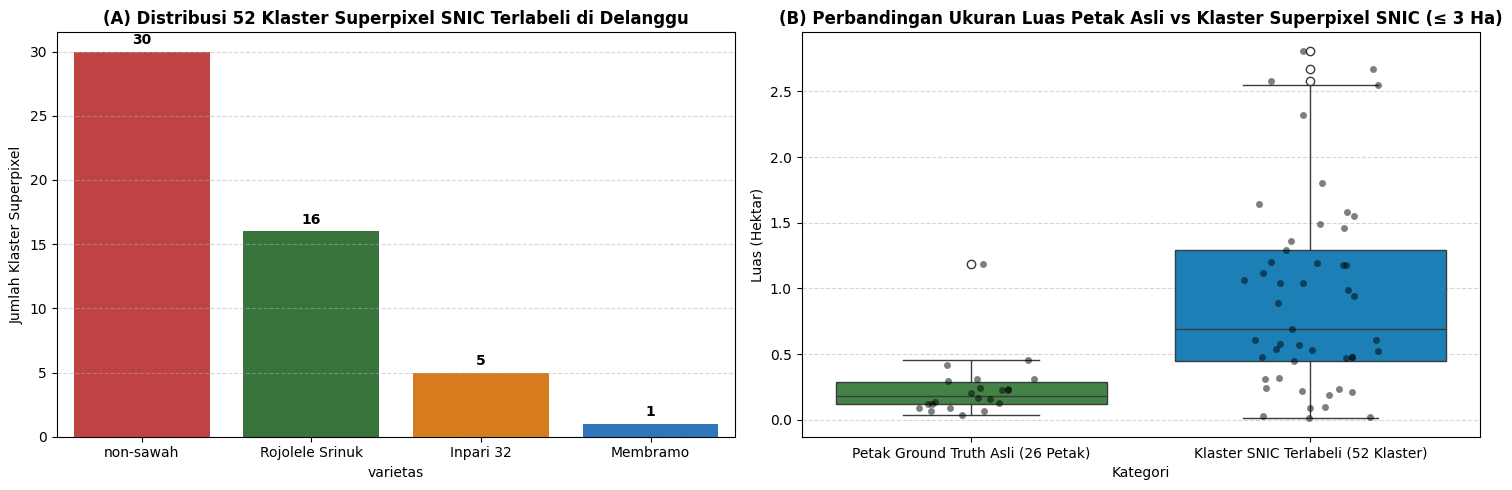

=== STATISTIK UKURAN KLASTER SNIC TERLABELI ===
Rata-rata Luas Klaster : 1.134 Ha (11338.5 m²)
Median Luas Klaster    : 0.915 Ha
Rentang Luas           : 0.010 Ha s/d 4.690 Ha


In [5]:
# 5. Analisis Rasio Tumpang Tindih Spasial & Komposisi 52 Klaster Latih Delanggu
labeled_clusters = gdf_clusters[gdf_clusters['kelas_sawah'] != 'unlabeled'].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Subplot 1: Komposisi 52 Klaster Terlabeli
cl_counts = labeled_clusters['varietas'].value_counts()
colors_cl = ['#d32f2f', '#2e7d32', '#f57c00', '#1976d2']
sns.barplot(x=cl_counts.index, y=cl_counts.values, palette=var_palette, ax=axes[0])
axes[0].set_title('(A) Distribusi 52 Klaster Superpixel SNIC Terlabeli di Delanggu', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Klaster Superpixel')
for i, v in enumerate(cl_counts.values):
    axes[0].text(i, v + 0.6, str(v), ha='center', fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.5, axis='y')

# Subplot 2: Perbandingan Luas Klaster SNIC vs Petak Ground Truth Lapangan
luas_comparison = pd.DataFrame({
    'Kategori': ['Petak Ground Truth Asli (26 Petak)'] * len(gdf_gt) + ['Klaster SNIC Terlabeli (52 Klaster)'] * len(labeled_clusters),
    'Luas_Ha': list(gdf_gt['area_ha']) + list(labeled_clusters['area_ha'])
})
# Filter agar non-sawah yang sangat besar tidak mendistorsi skala
luas_comp_filtered = luas_comparison[luas_comparison['Luas_Ha'] <= 3.0]

sns.boxplot(data=luas_comp_filtered, x='Kategori', y='Luas_Ha', palette=['#388e3c', '#0288d1'], ax=axes[1])
sns.stripplot(data=luas_comp_filtered, x='Kategori', y='Luas_Ha', color='black', alpha=0.5, jitter=0.2, ax=axes[1])
axes[1].set_title('(B) Perbandingan Ukuran Luas Petak Asli vs Klaster Superpixel SNIC (≤ 3 Ha)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Luas (Hektar)')
axes[1].grid(True, linestyle='--', alpha=0.5, axis='y')

plt.tight_layout()
plt.show()

print(f"=== STATISTIK UKURAN KLASTER SNIC TERLABELI ===")
print(f"Rata-rata Luas Klaster : {labeled_clusters['area_ha'].mean():.3f} Ha ({labeled_clusters['area_m2'].mean():.1f} m²)")
print(f"Median Luas Klaster    : {labeled_clusters['area_ha'].median():.3f} Ha")
print(f"Rentang Luas           : {labeled_clusters['area_ha'].min():.3f} Ha s/d {labeled_clusters['area_ha'].max():.3f} Ha")


---
## 🌐 6. Katalog Referensi Silang: Aset Google Earth Engine (GEE)

Untuk keperluan komputasi *cloud-native* pada skrip Earth Engine (`src/B1_delanggu_snic_gee_editor.js` dan `src/B3_delanggu_landsat_sentinel_pipeline.js`), seluruh data spasial di atas telah diunggah dan terhubung dengan ID aset GEE pengguna (`users/mhakimgf/*`):

| No | Nama Aset GEE Pengguna | Wilayah Administrasi | Kategori / Varietas Terkandung | File Sumber GeoJSON Lokal |
| :--- | :--- | :--- | :--- | :--- |
| 1 | `users/mhakimgf/ground_truth_klaten_final_labeled` | Kab. Klaten | Srinuk, Inpari 32, Membramo, Mapan | `data/raw/Data Dikasih/Klaten/*.geojson` |
| 2 | `users/mhakimgf/Salatiga/ground_truth_salatiga_final_labeled` | Kota Salatiga | Inpari 32 (Multi-Fase Pertumbuhan) | `data/raw/Data Dikasih/Salatiga/*.geojson` |
| 3 | `users/mhakimgf/inpari32_tingkir_2_bulan_260326` | Kec. Tingkir, Salatiga | Inpari 32 Fase Vegetatif 2 Bulan | `SL3_15_Inpari 32_Tingkir_2 Bulan.geojson` |
| 4 | `users/mhakimgf/inpari32_tingkir_3_bulan_260326` | Kec. Tingkir, Salatiga | Inpari 32 Fase Generatif 3 Bulan | `SL3_17_Inpari 32_Tingkir_3 Bulan.geojson` |
| 5 | `users/mhakimgf/inpari32_delanggu_3_bulan_200326` | Kec. Delanggu, Klaten | Inpari 32 Umur 3 Bulan | `08_Inpari_KecDelanggu_3 Bulan.geojson` |
| 6 | `users/mhakimgf/inpari32_delanggu_3_5_bulan_200326` | Kec. Delanggu, Klaten | Inpari 32 Umur 3.5 Bulan | `06_Inpari_KecDelanggu_3,5 Bulan.geojson` |
| 7 | `users/mhakimgf/membramo_delanggu_3_bulan_200326` | Kec. Delanggu, Klaten | Membramo Umur 3 Bulan | `07_Membramo_KecDelanggu_3 Bulan.geojson` |
| 8 | `users/mhakimgf/inpari32_tulung_1_bulan_200326` | Kec. Tulung, Klaten | Inpari 32 Umur 1 Bulan | `02_32_KecTulung_1 Bulanl.geojson` |
| 9 | `users/mhakimgf/inpari32_tulung_3_bulan_200326` | Kec. Tulung, Klaten | Inpari 32 Umur 3 Bulan | `01_32_KecTulung_3 Bulan.geojson` |
| 10 | `users/mhakimgf/mapan_tulung_3_bulan_200326` | Kec. Tulung, Klaten | Padi Hibrida Mapan Umur 3 Bulan | `03_Mapan_Kecamatan Tulung_3 Bulan.geojson` |
| 11 | `users/mhakimgf/polygon_sawah` | Kabupaten Klaten | Masking Poligon Lahan Sawah Baku | Shapefile Lahan Baku Sawah ATR/BPN |

---

### 💡 Kesimpulan Pengelolaan Ground Truth
1. **Keterwakilan Spesifik**: Data referensi telah mencakup varietas target (**Rojolele Srinuk**) dan tiga varietas pembanding mayoritas di Jawa Tengah (**Inpari 32, Membramo, Mapan**).
2. **Keterwakilan Temporal**: Rentang usia tanaman mulai dari 1 minggu hingga 3.5 bulan memberikan spektrum profil kurva fenologi yang lengkap untuk melatih pita kendala Sakoe-Chiba DTW.
3. **Keterwakilan Spasial Lintas Wilayah**: Keberadaan data referensi di dua kabupaten (Klaten dan Salatiga) membuka peluang emas bagi validasi generalisasi model (*cross-region inference*) pada pengembangan bab Tugas Akhir selanjutnya.